# Adaline - Mateo Maldonado (98717)

* Reutilizando (o no) el código de la Notebook 06 Redes Neuronales 2da parte, entrenar un Adaline para clasificar el problema de los cúmulos de puntos rojos y azules (ver Notebook 05 - Redes Neuronales 1ra parte). Definir condición de corte o cantidad máxima de epochs.
* Graficar la frontera entre clases. Indicar qué diferencia notan en el gráfico.

**Fórmulas que voy a usar**

* Salida del Adaline (activación lineal, con $x_0 = 1$):
$$O = Net = w_0 x_0 + w_1 x_1 + w_2 x_2$$

* Error cuadrático medio:
$$E = \frac{1}{2L} \sum_{k=1}^{L}(y_k - O_k)^2$$

* Regla delta:
$$\Delta w_i = \alpha \, (y_k - O_k) \, x_i \qquad w_{nuevo} = w + \Delta w$$

* Clasificación (las clases son 1 = azul y 0 = rojo, así que corto en el medio):
$$\text{clase} = \begin{cases} \text{azul} & \text{si } O > 0.5 \\ \text{rojo} & \text{si } O \le 0.5 \end{cases}$$

* Frontera entre clases ($O = 0.5$):
$$x_2 = \frac{0.5 - w_0 - w_1 x_1}{w_2}$$

## Paso 1. Importación de librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(12)  # para que los datos y los pesos iniciales den siempre lo mismo

## Paso 2. Generar los datos
Uso el mismo generador de la Notebook 05: 120 puntos azules (clase 1) alrededor de un centro y 120 puntos rojos (clase 0) alrededor de otro. Cada fila de X tiene el 1 fijo (x0) en la primera columna, y después x1 y x2.

In [2]:
def gendata4(p1,p2,p3,p4,cant,delta):
    data_x1 = np.zeros ((cant,3))
    data_x2 = np.zeros ((cant,3))
    data_x3 = np.zeros ((cant,3))
    data_x4 = np.zeros ((cant,3))
    for i in range(cant):
        data_x1[i,0] = 1
        data_x1[i,1] = np.random.normal(-delta,delta) + p1[0]
        data_x1[i,2] = np.random.normal(-delta,delta) + p1[1]
        data_x2[i,0] = 1
        data_x2[i,1] = np.random.normal(-delta,delta) + p2[0]
        data_x2[i,2] = np.random.normal(-delta,delta) + p2[1]
        data_x3[i,0] = 1
        data_x3[i,1] = np.random.normal(-delta,delta) + p3[0]
        data_x3[i,2] = np.random.normal(-delta,delta) + p3[1]
        data_x4[i,0] = 1
        data_x4[i,1] = np.random.normal(-delta,delta) + p4[0]
        data_x4[i,2] = np.random.normal(-delta,delta) + p4[1]
    return data_x1, data_x2, data_x3, data_x4

L = 60 # Cantidad de datos por cluster
d = 1
punto_a = np.array((2,3))
punto_b = np.array((2,3))
punto_c = np.array((8,7))
punto_d = np.array((8,7))
datos_a, datos_b, datos_c, datos_d = gendata4(punto_a,punto_b,punto_c,punto_d,L,d)
X = np.vstack((datos_a,datos_b,datos_c,datos_d))
Y = np.hstack((np.ones(2*L),0*np.ones(2*L)))

print('Cantidad de vectores:', len(X))
print('Primeras 3 filas de X:\n', X[:3].round(2))

Cantidad de vectores: 240
Primeras 3 filas de X:
 [[1.   1.47 1.32]
 [1.   0.19 4.87]
 [1.   2.01 1.09]]


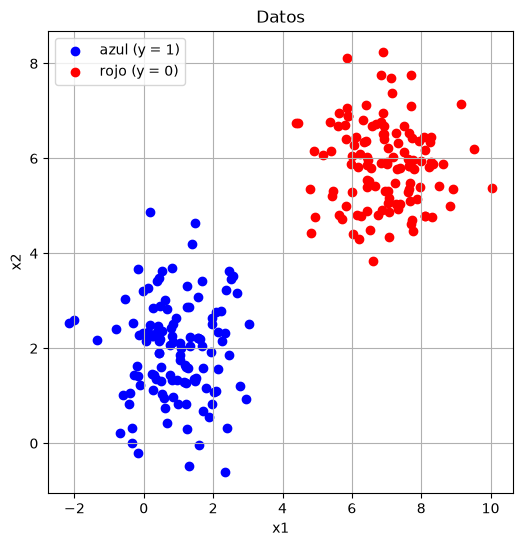

In [3]:
azul = Y == 1
rojo = Y == 0

plt.figure(figsize=(6, 6))
plt.scatter(X[azul,1], X[azul,2], color='b', label='azul (y = 1)')
plt.scatter(X[rojo,1], X[rojo,2], color='r', label='rojo (y = 0)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Datos')
plt.legend()
plt.grid(True)
plt.show()

## Paso 3. Definir la tasa de aprendizaje, los pesos iniciales y la condición de corte
En el Adaline el error nunca llega a 0, así que no puedo cortar cuando no haya errores como en el perceptrón. Uso dos condiciones y corta la primera que se cumpla:
* **El error se estabiliza:** si de una época a la otra el error cambia menos de 0.0000001, ya no está aprendiendo nada nuevo.
* **Máximo de 500 épocas:** por si no llega a estabilizarse, para que no quede corriendo para siempre.

Uso α = 0.0015 porque los puntos llegan hasta x ≈ 10 y con un α mucho más grande (por ejemplo 0.03) las correcciones son muy grandes y el error, en vez de bajar, crece. Los pesos iniciales son valores chicos al azar.

In [4]:
alfa = 0.0015
max_epocas = 500
tolerancia = 0.0000001

w = np.random.uniform(-0.5, 0.5, size=3)
w_inicial = w.copy()

print('alfa =', alfa)
print('max_epocas =', max_epocas)
print('tolerancia =', tolerancia)
print('w inicial =', w.round(4))

alfa = 0.0015
max_epocas = 500
tolerancia = 1e-07
w inicial = [ 0.1445 -0.4214  0.3872]


## Paso 4. Entrenar el Adaline
En cada época paso los 240 vectores uno por uno. Para cada vector calculo la salida O, el error (y − O) y corrijo los pesos con la regla delta. Al terminar la época calculo el error cuadrático medio con todos los puntos y me fijo si se cumple alguna condición de corte.

A diferencia del perceptrón, acá los pesos cambian con **todos** los vectores, no solo con los mal clasificados, porque el error casi nunca da 0 exacto.

In [5]:
# error antes de entrenar
E = 0
for k in range(len(X)):
    O = w[0]*X[k,0] + w[1]*X[k,1] + w[2]*X[k,2]
    E = E + (Y[k] - O)**2
E = E / (2*len(X))

errores = [E]
print(f'Época 0: E = {E:.6f}')

for epoca in range(1, max_epocas + 1):

    # recorro los vectores uno por uno
    for k in range(len(X)):
        O = w[0]*X[k,0] + w[1]*X[k,1] + w[2]*X[k,2]   # salida (lineal)
        error = Y[k] - O                                # error de este vector
        w[0] = w[0] + alfa * error * X[k,0]             # regla delta
        w[1] = w[1] + alfa * error * X[k,1]
        w[2] = w[2] + alfa * error * X[k,2]

    # error cuadrático medio de la época
    E = 0
    for k in range(len(X)):
        O = w[0]*X[k,0] + w[1]*X[k,1] + w[2]*X[k,2]
        E = E + (Y[k] - O)**2
    E = E / (2*len(X))
    errores.append(E)

    if epoca <= 5 or epoca % 10 == 0:
        print(f'Época {epoca}: E = {E:.6f}   w = {w.round(4)}')

    # condición de corte
    if abs(errores[-2] - errores[-1]) < tolerancia:
        print(f'\nÉpoca {epoca}: E = {E:.6f}   w = {w.round(4)}')
        print(f'Corta en la época {epoca} porque el error se estabilizó (cambió menos de {tolerancia})')
        break

if epoca == max_epocas:
    print(f'\nCorta porque llegó al máximo de {max_epocas} épocas')

print('\nPesos finales:', w.round(4))

Época 0: E = 0.287242
Época 1: E = 0.146053   w = [ 0.1956 -0.2963  0.3205]
Época 2: E = 0.121935   w = [ 0.2381 -0.2392  0.2453]
Época 3: E = 0.107896   w = [ 0.2846 -0.203   0.1943]
Época 4: E = 0.097419   w = [ 0.3323 -0.1798  0.1585]
Época 5: E = 0.088414   w = [ 0.3796 -0.1644  0.1323]
Época 10: E = 0.054516   w = [ 0.589  -0.134   0.0608]
Época 20: E = 0.023852   w = [ 0.8618 -0.1164 -0.0062]
Época 30: E = 0.014337   w = [ 1.0079 -0.1078 -0.0409]
Época 40: E = 0.011248   w = [ 1.0859 -0.1032 -0.0595]
Época 50: E = 0.010168   w = [ 1.1276 -0.1008 -0.0694]
Época 60: E = 0.009753   w = [ 1.1499 -0.0995 -0.0747]
Época 70: E = 0.009578   w = [ 1.1618 -0.0988 -0.0776]
Época 80: E = 0.009498   w = [ 1.1681 -0.0984 -0.0791]
Época 90: E = 0.009458   w = [ 1.1715 -0.0982 -0.0799]
Época 100: E = 0.009439   w = [ 1.1733 -0.0981 -0.0803]
Época 110: E = 0.009428   w = [ 1.1743 -0.098  -0.0806]
Época 120: E = 0.009423   w = [ 1.1748 -0.098  -0.0807]
Época 130: E = 0.009420   w = [ 1.1751 -0.098

## Paso 5. Graficar el error en cada época
Para ver cómo fue bajando el error durante el entrenamiento.

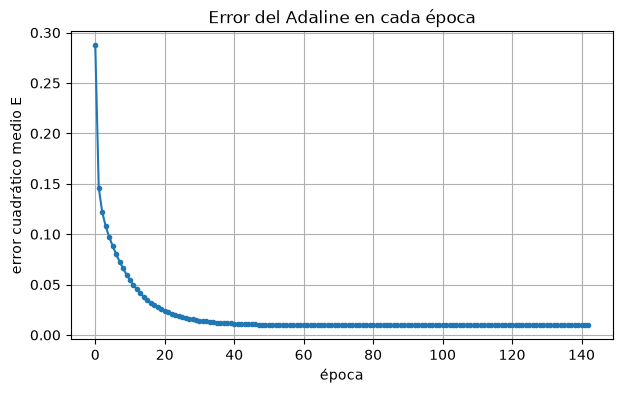

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(errores, marker='.')
plt.xlabel('época')
plt.ylabel('error cuadrático medio E')
plt.title('Error del Adaline en cada época')
plt.grid(True)
plt.show()

El error baja muy rápido en las primeras épocas y después se aplana, pero nunca llega a 0. Por eso hace falta la condición de corte.

## Paso 6. Calcular las salidas del clasificador
Con los pesos finales calculo O para cada punto, lo clasifico (azul si O > 0.5, rojo si no) y cuento cuántos aciertos hay.

In [7]:
aciertos = 0
suma_azul = 0
suma_rojo = 0
for k in range(len(X)):
    O = w[0]*X[k,0] + w[1]*X[k,1] + w[2]*X[k,2]
    if O > 0.5:
        clase = 1
    else:
        clase = 0
    if clase == Y[k]:
        aciertos = aciertos + 1
    if Y[k] == 1:
        suma_azul = suma_azul + O
    else:
        suma_rojo = suma_rojo + O

print(f'Aciertos: {aciertos} de {len(X)}')
print(f'Salida promedio en los azules: {suma_azul/120:.3f}  (esperada 1)')
print(f'Salida promedio en los rojos:  {suma_rojo/120:.3f}  (esperada 0)')

Aciertos: 240 de 240
Salida promedio en los azules: 0.926  (esperada 1)
Salida promedio en los rojos:  0.023  (esperada 0)


Clasifica bien todos los puntos. La salida no da exactamente 1 o 0 porque el Adaline es lineal: da un número real que se acerca a la etiqueta.

## Paso 7. Graficar la frontera del Adaline
La frontera es donde O = 0.5. Despejo x2 con los pesos finales:

In [8]:
w0, w1, w2 = w[0], w[1], w[2]
print(f'{w0:.4f} + ({w1:.4f})*x1 + ({w2:.4f})*x2 = 0.5')
print(f'({w2:.4f})*x2 = 0.5 - {w0:.4f} - ({w1:.4f})*x1')
print(f'x2 = (0.5 - {w0:.4f} - ({w1:.4f})*x1) / ({w2:.4f})')
print(f'x2 = {(0.5 - w0)/w2:.4f} + ({-w1/w2:.4f})*x1')

1.1753 + (-0.0980)*x1 + (-0.0808)*x2 = 0.5
(-0.0808)*x2 = 0.5 - 1.1753 - (-0.0980)*x1
x2 = (0.5 - 1.1753 - (-0.0980)*x1) / (-0.0808)
x2 = 8.3578 + (-1.2126)*x1


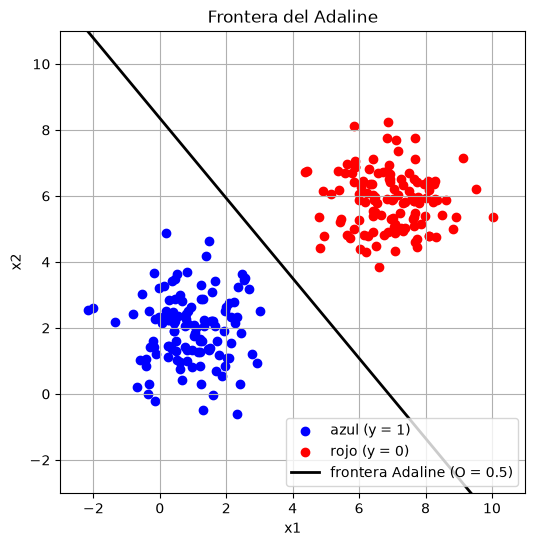

In [9]:
recta_x1 = np.linspace(-3, 11, 100)
recta_adaline = (0.5 - w[0] - w[1]*recta_x1) / w[2]

plt.figure(figsize=(6, 6))
plt.scatter(X[azul,1], X[azul,2], color='b', label='azul (y = 1)')
plt.scatter(X[rojo,1], X[rojo,2], color='r', label='rojo (y = 0)')
plt.plot(recta_x1, recta_adaline, color='black', linewidth=2, label='frontera Adaline (O = 0.5)')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Frontera del Adaline')
plt.legend(loc='lower right')
plt.grid(True)
plt.xlim(-3, 11)
plt.ylim(-3, 11)
plt.show()

## Paso 8. Entrenar un perceptrón con los mismos datos para comparar
Para ver qué diferencia hay, entreno un perceptrón con los mismos puntos y los mismos pesos iniciales: salida 1 si net > 0 (0 si no), α = 1, y corta cuando pasa una época entera sin errores.

In [10]:
wp = w_inicial.copy()

for epoca in range(1, 101):
    cantidad_errores = 0
    for k in range(len(X)):
        net = wp[0]*X[k,0] + wp[1]*X[k,1] + wp[2]*X[k,2]
        if net > 0:
            salida = 1
        else:
            salida = 0
        error = Y[k] - salida
        if error != 0:
            wp[0] = wp[0] + 1 * error * X[k,0]
            wp[1] = wp[1] + 1 * error * X[k,1]
            wp[2] = wp[2] + 1 * error * X[k,2]
            cantidad_errores = cantidad_errores + 1
    print(f'Época {epoca}: {cantidad_errores} errores   w = {wp.round(4)}')
    if cantidad_errores == 0:
        print(f'\nEl perceptrón termina en la época {epoca}')
        break

Época 1: 2 errores   w = [ 0.1445 -6.1621 -2.9919]
Época 2: 5 errores   w = [ 3.1445 -7.829   0.1316]
Época 3: 5 errores   w = [ 6.1445 -7.3514 -2.2216]
Época 4: 4 errores   w = [ 8.1445 -9.2113 -3.9699]
Época 5: 5 errores   w = [ 11.1445 -10.8782  -0.8463]
Época 6: 4 errores   w = [13.1445 -9.7664 -3.4819]
Época 7: 3 errores   w = [16.1445 -3.8732 -0.7649]
Época 8: 0 errores   w = [16.1445 -3.8732 -0.7649]

El perceptrón termina en la época 8


## Paso 9. Graficar las dos fronteras juntas
La del perceptrón es donde net = 0, o sea x2 = −(w0 + w1·x1) / w2. La del Adaline es donde O = 0.5.

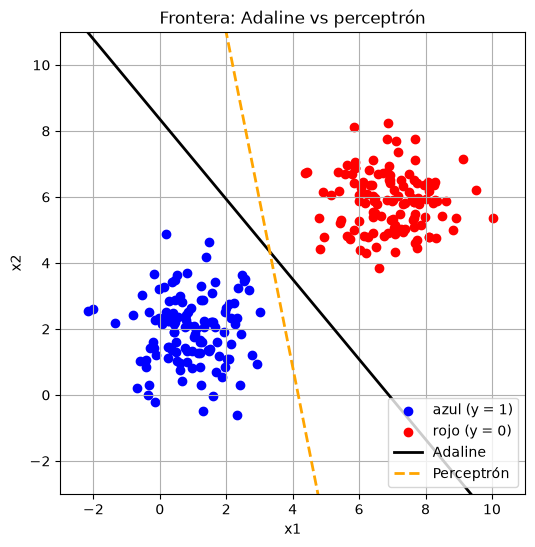

In [11]:
recta_perceptron = -(wp[0] + wp[1]*recta_x1) / wp[2]

plt.figure(figsize=(6, 6))
plt.scatter(X[azul,1], X[azul,2], color='b', label='azul (y = 1)')
plt.scatter(X[rojo,1], X[rojo,2], color='r', label='rojo (y = 0)')
plt.plot(recta_x1, recta_adaline, color='black', linewidth=2, label='Adaline')
plt.plot(recta_x1, recta_perceptron, color='orange', linewidth=2, linestyle='--', label='Perceptrón')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Frontera: Adaline vs perceptrón')
plt.legend(loc='lower right')
plt.grid(True)
plt.xlim(-3, 11)
plt.ylim(-3, 11)
plt.show()

## ¿Qué diferencia se nota en el gráfico?

Las dos rectas separan bien los puntos azules de los rojos, pero quedan en lugares muy distintos:

* **Adaline:** la recta cruza entre los dos cúmulos, más o menos por el medio y casi perpendicular a la dirección que va de un cúmulo al otro. Deja un margen parecido hacia cada lado, así que si aparece un punto nuevo un poco alejado de su cúmulo, lo más probable es que lo clasifique bien igual.
* **Perceptrón:** la recta queda casi vertical y pasa rozando el borde del cúmulo azul. Clasifica bien todos los puntos de entrenamiento, pero con muy poco margen del lado azul: un punto azul apenas más a la derecha ya quedaría del lado equivocado.

La diferencia viene de cómo aprende cada uno. El perceptrón solo cambia los pesos cuando se equivoca, entonces en cuanto encuentra una recta que separa todo (en la época 8) se queda quieto, aunque esa recta esté muy cerca de una de las clases. Cuál recta encuentra depende de los pesos iniciales y del orden en que recorre los puntos. El Adaline, en cambio, ajusta los pesos con todos los puntos porque busca minimizar el error cuadrático, no solo acertar la clase. Por eso sigue corrigiendo aunque ya clasifique todo bien (acierta los 240 puntos desde la época 21 y sigue hasta la 142), y la recta termina en una posición equilibrada entre los dos cúmulos.

También cambia cuándo termina el entrenamiento: el perceptrón llega a 0 errores y se detiene solo, mientras que el error del Adaline nunca llega a 0 (se queda en ≈ 0.0094), así que necesita la condición de corte. En este caso cortó porque el error dejó de cambiar.